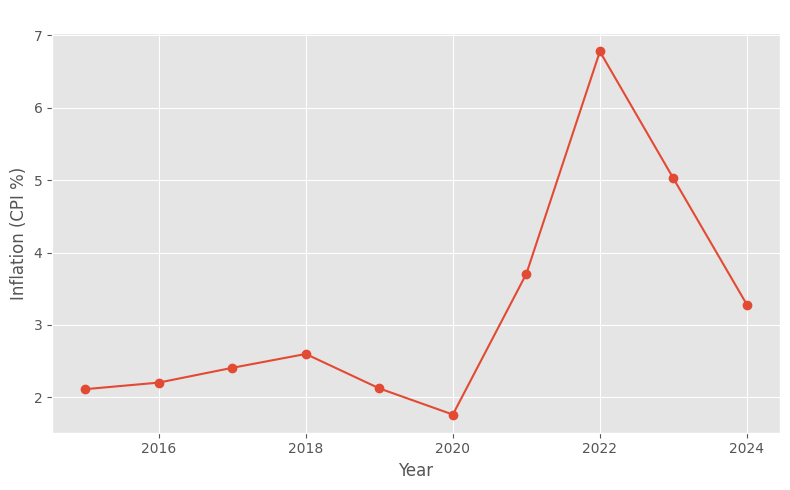

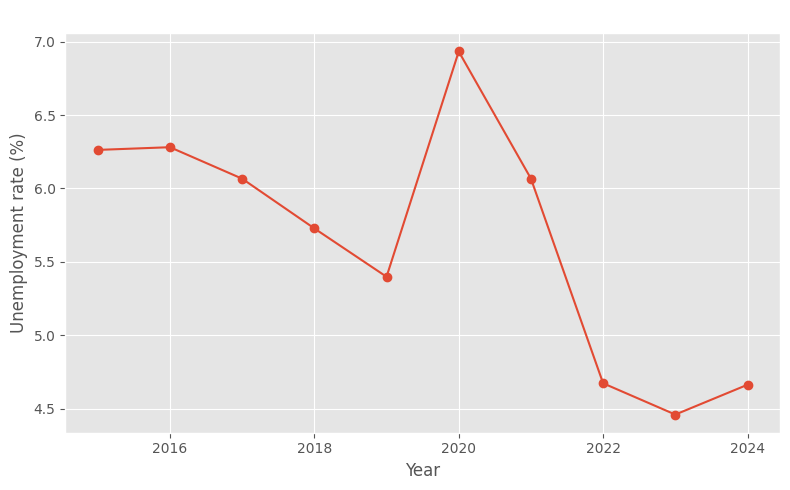

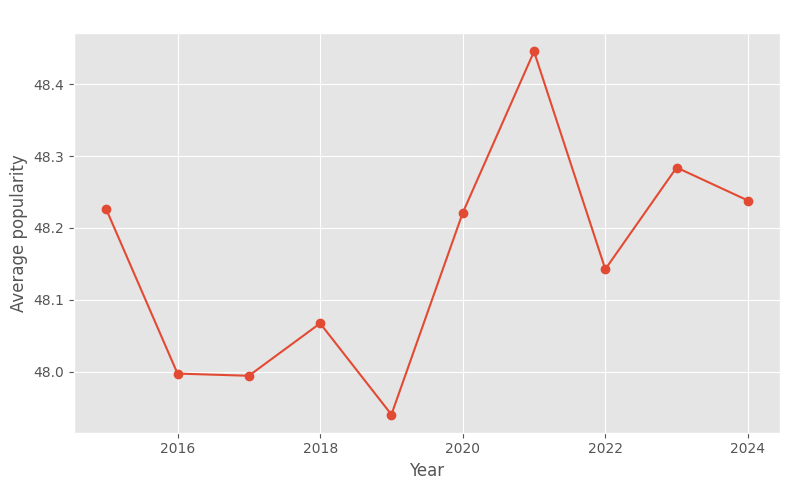

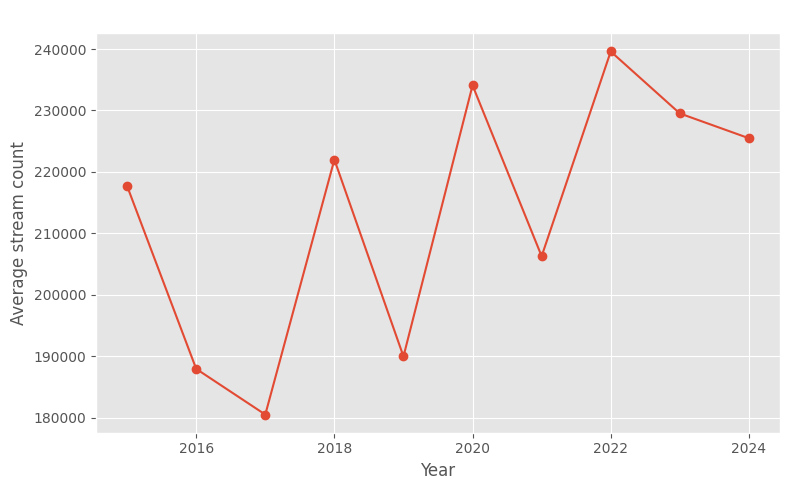

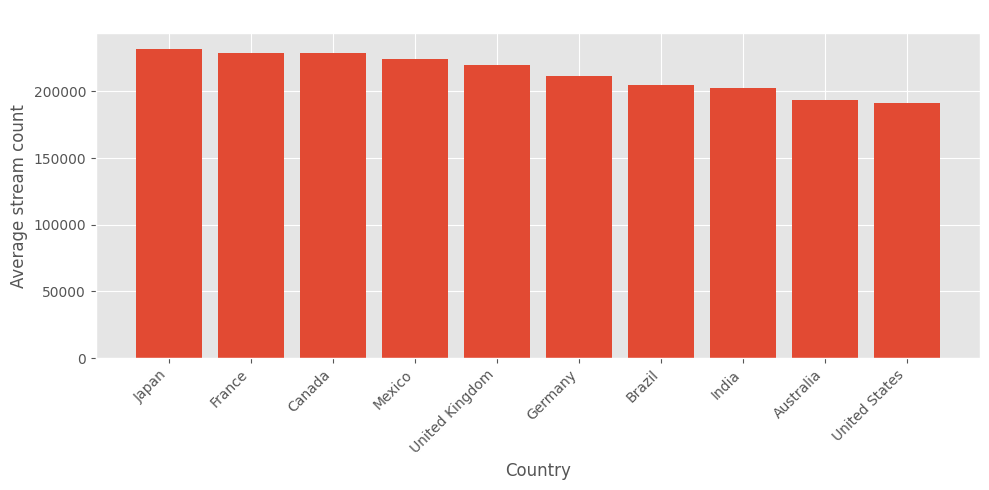

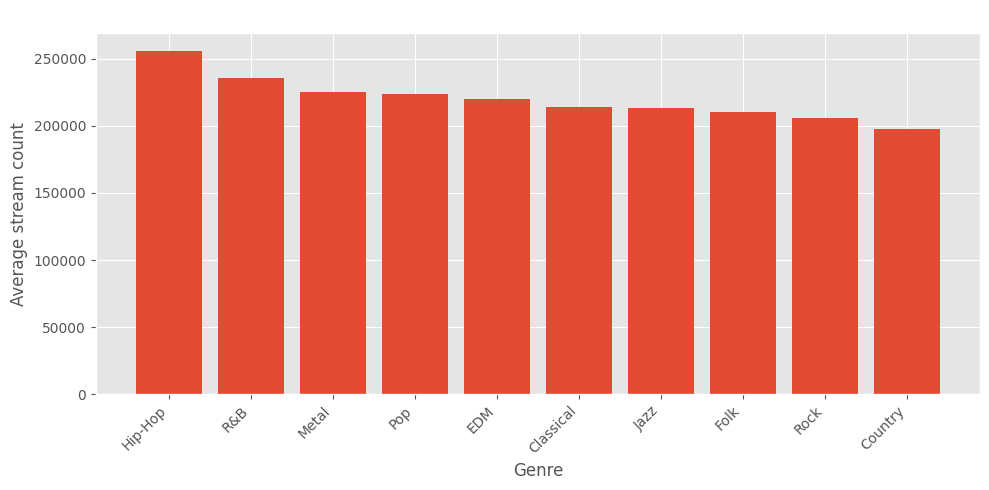

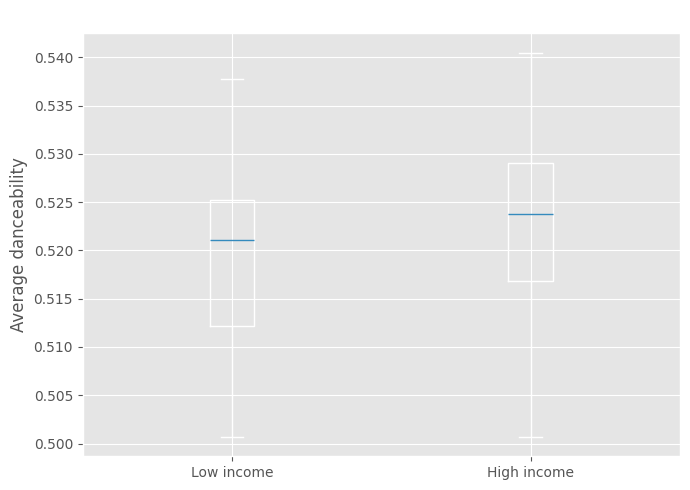

Done. Files saved in: /Users/seyhankasap/PycharmProjects/DSAtermproj/dsa210-proj/outputs
                                          hypothesis   p_value  \
0          H1: Popularity differs by inflation group  0.512121   
1   H2: Explicit share differs by unemployment group  0.102015   
2  H3: Danceability differs by income-per-capita ...  0.016858   

   secondary_p_value  mean_high   mean_low  
0           0.676623  48.194162  48.117161  
1           0.142937   0.203794   0.199551  
2           0.026475   0.523355   0.518741  


In [5]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("ggplot")
from scipy import stats


BASE_DIR = Path("../data/raw")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


def standardize_country(name: str) -> str:
    if pd.isna(name):
        return np.nan
    name = str(name).strip()
    mapping = {
        "United States of America": "United States",
        "USA": "United States",
        "US": "United States",
        "U.S.": "United States",
        "U.S.A.": "United States",
        "UK": "United Kingdom",
        "U.K.": "United Kingdom",
    }
    return mapping.get(name, name)


def safe_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def load_data():
    spotify = pd.read_csv(BASE_DIR / "spotify_2015_2025_85k.csv")
    global_econ = pd.read_csv(BASE_DIR / "Global Economy Indicators.csv")
    wb = pd.read_csv(BASE_DIR / "world_bank_data_2025.csv")
    return spotify, global_econ, wb


def clean_spotify(spotify: pd.DataFrame) -> pd.DataFrame:
    spotify = spotify.copy()
    spotify["country"] = spotify["country"].apply(standardize_country)
    spotify["release_date"] = pd.to_datetime(spotify["release_date"], errors="coerce")
    spotify["year"] = spotify["release_date"].dt.year

    numeric_cols = [
        "duration_ms", "popularity", "danceability", "energy", "loudness",
        "instrumentalness", "tempo", "stream_count", "explicit"
    ]
    spotify = safe_numeric(spotify, numeric_cols)

    spotify["explicit"] = spotify["explicit"].fillna(0).astype(int)
    spotify["genre"] = spotify["genre"].astype(str).str.strip()
    spotify["artist_name"] = spotify["artist_name"].astype(str).str.strip()
    spotify["track_name"] = spotify["track_name"].astype(str).str.strip()

    spotify = spotify.dropna(subset=["country", "year"])
    spotify = spotify[spotify["year"].between(2015, 2025)].copy()

    return spotify


def clean_global_econ(global_econ: pd.DataFrame) -> pd.DataFrame:
    global_econ = global_econ.copy()
    global_econ.columns = [c.strip() for c in global_econ.columns]
    if "Country" in global_econ.columns:
        global_econ["Country"] = global_econ["Country"].apply(standardize_country)
    if "Year" in global_econ.columns:
        global_econ["Year"] = pd.to_numeric(global_econ["Year"], errors="coerce")

    use_cols = [
        "Country", "Year", "Per capita GNI",
        "Gross National Income(GNI) in USD",
        "Gross Domestic Product (GDP)"
    ]
    global_econ = global_econ[use_cols].copy()
    global_econ = safe_numeric(
        global_econ,
        ["Per capita GNI", "Gross National Income(GNI) in USD", "Gross Domestic Product (GDP)"]
    )
    global_econ = global_econ.rename(columns={
        "Country": "country",
        "Year": "year",
        "Per capita GNI": "gni_per_capita_global",
        "Gross National Income(GNI) in USD": "gni_usd_global",
        "Gross Domestic Product (GDP)": "gdp_usd_global"
    })
    return global_econ


def clean_world_bank(wb: pd.DataFrame) -> pd.DataFrame:
    wb = wb.copy()
    wb["country_name"] = wb["country_name"].apply(standardize_country)
    wb["year"] = pd.to_numeric(wb["year"], errors="coerce")

    use_cols = [
        "country_name", "year", "Inflation (CPI %)", "GDP (Current USD)",
        "GDP per Capita (Current USD)", "Unemployment Rate (%)",
        "Gross National Income (USD)"
    ]
    wb = wb[use_cols].copy()
    wb = safe_numeric(
        wb,
        [
            "Inflation (CPI %)", "GDP (Current USD)", "GDP per Capita (Current USD)",
            "Unemployment Rate (%)", "Gross National Income (USD)"
        ]
    )
    wb = wb.rename(columns={
        "country_name": "country",
        "Inflation (CPI %)": "inflation_cpi",
        "GDP (Current USD)": "gdp_usd_wb",
        "GDP per Capita (Current USD)": "gdp_per_capita_wb",
        "Unemployment Rate (%)": "unemployment_rate",
        "Gross National Income (USD)": "gni_usd_wb"
    })
    return wb


def merge_data(spotify: pd.DataFrame, global_econ: pd.DataFrame, wb: pd.DataFrame) -> pd.DataFrame:
    merged = spotify.merge(global_econ, on=["country", "year"], how="left")
    merged = merged.merge(wb, on=["country", "year"], how="left")

    # Final analysis columns (prefer World Bank, then fall back to older global dataset where sensible)
    merged["gdp_usd"] = merged["gdp_usd_wb"].combine_first(merged["gdp_usd_global"])
    merged["gni_usd"] = merged["gni_usd_wb"].combine_first(merged["gni_usd_global"])

    # This is intentionally labeled as income_per_capita because the fallback source is GNI per capita.
    merged["income_per_capita"] = merged["gdp_per_capita_wb"].combine_first(merged["gni_per_capita_global"])

    return merged


def build_country_year_panel(merged: pd.DataFrame) -> pd.DataFrame:
    panel = (
        merged.groupby(["country", "year"], as_index=False)
        .agg(
            n_tracks=("track_id", "count"),
            avg_popularity=("popularity", "mean"),
            avg_danceability=("danceability", "mean"),
            avg_energy=("energy", "mean"),
            avg_stream_count=("stream_count", "mean"),
            explicit_share=("explicit", "mean"),
            inflation_cpi=("inflation_cpi", "mean"),
            unemployment_rate=("unemployment_rate", "mean"),
            income_per_capita=("income_per_capita", "mean"),
            gdp_usd=("gdp_usd", "mean"),
            gni_usd=("gni_usd", "mean"),
        )
    )
    return panel


def save_missingness(merged: pd.DataFrame):
    missingness = pd.DataFrame({
        "column": merged.columns,
        "missing_count": merged.isna().sum().values,
        "missing_pct": (merged.isna().mean().values * 100).round(2)
    }).sort_values(["missing_pct", "missing_count"], ascending=False)
    missingness.to_csv(OUTPUT_DIR / "missingness_summary.csv", index=False)


def plot_series(df: pd.DataFrame, x: str, y: str, filename: str, title: str, ylabel: str):
    plot_df = df.groupby(x, as_index=False)[y].mean().dropna()
    plt.figure(figsize=(8, 5))
    plt.plot(plot_df[x], plot_df[y], marker="o")
    plt.title(title)
    plt.xlabel(x.capitalize())
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300)
    plt.show()
    plt.close()


def plot_bar(df: pd.DataFrame, x: str, y: str, filename: str, title: str, ylabel: str, top_n: int | None = None):
    plot_df = df.groupby(x, as_index=False)[y].mean().dropna().sort_values(y, ascending=False)
    if top_n is not None:
        plot_df = plot_df.head(top_n)
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df[x], plot_df[y])
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.xlabel(x.capitalize())
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300)
    plt.show()
    plt.close()


def plot_box(panel: pd.DataFrame):
    h3_df = panel.dropna(subset=["income_per_capita", "avg_danceability"]).copy()
    median_income = h3_df["income_per_capita"].median()
    h3_df["income_group"] = np.where(h3_df["income_per_capita"] >= median_income, "High income", "Low income")

    values = [
        h3_df.loc[h3_df["income_group"] == "Low income", "avg_danceability"].values,
        h3_df.loc[h3_df["income_group"] == "High income", "avg_danceability"].values,
    ]
    plt.figure(figsize=(7, 5))
    plt.boxplot(values, labels=["Low income", "High income"])
    plt.title("Average danceability by income-per-capita group")
    plt.ylabel("Average danceability")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "danceability_by_income_group.png", dpi=300)
    plt.show()
    plt.close()



def cohens_d(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_std = np.sqrt(((nx - 1) * vx + (ny - 1) * vy) / (nx + ny - 2))
    if pooled_std == 0:
        return np.nan
    return (np.mean(x) - np.mean(y)) / pooled_std


def run_hypothesis_tests(panel: pd.DataFrame) -> pd.DataFrame:
    results = []

    # H1: Average popularity differs between high-inflation and low-inflation country-years.
    h1 = panel.dropna(subset=["inflation_cpi", "avg_popularity"]).copy()
    infl_median = h1["inflation_cpi"].median()
    high = h1.loc[h1["inflation_cpi"] >= infl_median, "avg_popularity"].values
    low = h1.loc[h1["inflation_cpi"] < infl_median, "avg_popularity"].values
    t_stat, p_val = stats.ttest_ind(high, low, equal_var=False, nan_policy="omit")
    mw_stat, mw_p = stats.mannwhitneyu(high, low, alternative="two-sided")
    results.append({
        "hypothesis": "H1: Popularity differs by inflation group",
        "high_group_definition": f"inflation >= median ({infl_median:.3f})",
        "n_high": len(high),
        "n_low": len(low),
        "mean_high": np.mean(high),
        "mean_low": np.mean(low),
        "test": "Welch t-test",
        "statistic": t_stat,
        "p_value": p_val,
        "effect_size_cohens_d": cohens_d(high, low),
        "secondary_test": "Mann-Whitney U",
        "secondary_statistic": mw_stat,
        "secondary_p_value": mw_p,
    })

    # H2: Explicit-song share differs between high-unemployment and low-unemployment country-years.
    h2 = panel.dropna(subset=["unemployment_rate", "explicit_share"]).copy()
    unemp_median = h2["unemployment_rate"].median()
    high = h2.loc[h2["unemployment_rate"] >= unemp_median, "explicit_share"].values
    low = h2.loc[h2["unemployment_rate"] < unemp_median, "explicit_share"].values
    t_stat, p_val = stats.ttest_ind(high, low, equal_var=False, nan_policy="omit")
    mw_stat, mw_p = stats.mannwhitneyu(high, low, alternative="two-sided")
    results.append({
        "hypothesis": "H2: Explicit share differs by unemployment group",
        "high_group_definition": f"unemployment >= median ({unemp_median:.3f})",
        "n_high": len(high),
        "n_low": len(low),
        "mean_high": np.mean(high),
        "mean_low": np.mean(low),
        "test": "Welch t-test",
        "statistic": t_stat,
        "p_value": p_val,
        "effect_size_cohens_d": cohens_d(high, low),
        "secondary_test": "Mann-Whitney U",
        "secondary_statistic": mw_stat,
        "secondary_p_value": mw_p,
    })

    # H3: Average danceability differs between high-income-per-capita and low-income-per-capita country-years.
    h3 = panel.dropna(subset=["income_per_capita", "avg_danceability"]).copy()
    income_median = h3["income_per_capita"].median()
    high = h3.loc[h3["income_per_capita"] >= income_median, "avg_danceability"].values
    low = h3.loc[h3["income_per_capita"] < income_median, "avg_danceability"].values
    t_stat, p_val = stats.ttest_ind(high, low, equal_var=False, nan_policy="omit")
    mw_stat, mw_p = stats.mannwhitneyu(high, low, alternative="two-sided")
    results.append({
        "hypothesis": "H3: Danceability differs by income-per-capita group",
        "high_group_definition": f"income_per_capita >= median ({income_median:.3f})",
        "n_high": len(high),
        "n_low": len(low),
        "mean_high": np.mean(high),
        "mean_low": np.mean(low),
        "test": "Welch t-test",
        "statistic": t_stat,
        "p_value": p_val,
        "effect_size_cohens_d": cohens_d(high, low),
        "secondary_test": "Mann-Whitney U",
        "secondary_statistic": mw_stat,
        "secondary_p_value": mw_p,
    })

    results_df = pd.DataFrame(results)
    results_df.to_csv(OUTPUT_DIR / "hypothesis_test_results.csv", index=False)
    return results_df


def save_summary_text(spotify: pd.DataFrame, merged: pd.DataFrame, panel: pd.DataFrame, results: pd.DataFrame):
    lines = []
    lines.append("APRIL 14 DELIVERABLE SUMMARY")
    lines.append("=" * 40)
    lines.append(f"Spotify rows after cleaning: {len(spotify):,}")
    lines.append(f"Merged rows: {len(merged):,}")
    lines.append(f"Country-year panel rows: {len(panel):,}")
    lines.append("")
    lines.append("Coverage:")
    lines.append(f"- Countries in Spotify data: {spotify['country'].nunique()}")
    lines.append(f"- Years in Spotify data: {int(spotify['year'].min())}-{int(spotify['year'].max())}")
    lines.append("")
    lines.append("Hypothesis test results:")
    for _, row in results.iterrows():
        lines.append(
            f"- {row['hypothesis']}: p={row['p_value']:.4f} "
            f"(secondary p={row['secondary_p_value']:.4f}), "
            f"mean_high={row['mean_high']:.4f}, mean_low={row['mean_low']:.4f}"
        )
    (OUTPUT_DIR / "summary.txt").write_text("\n".join(lines), encoding="utf-8")


def main():
    spotify_raw, global_raw, wb_raw = load_data()

    spotify = clean_spotify(spotify_raw)
    global_econ = clean_global_econ(global_raw)
    wb = clean_world_bank(wb_raw)

    merged = merge_data(spotify, global_econ, wb)

    # Save cleaned merged file
    merged.to_csv(OUTPUT_DIR / "spotify_economy_merged_cleaned.csv", index=False)

    # Save a filtered "core" file for 2015-2024 because 2025 macro coverage is incomplete.
    core = merged[merged["year"].between(2015, 2024)].copy()
    core.to_csv(OUTPUT_DIR / "spotify_economy_core_2015_2024.csv", index=False)

    # Country-year panel
    panel = build_country_year_panel(core)
    panel.to_csv(OUTPUT_DIR / "country_year_panel_2015_2024.csv", index=False)

    # Missingness summary
    save_missingness(core)

    # EDA plots
    plot_series(panel, "year", "inflation_cpi", "avg_inflation_by_year.png",
                "Average inflation by year (2015-2024)", "Inflation (CPI %)")
    plot_series(panel, "year", "unemployment_rate", "avg_unemployment_by_year.png",
                "Average unemployment by year (2015-2024)", "Unemployment rate (%)")
    plot_series(panel, "year", "avg_popularity", "avg_popularity_by_year.png",
                "Average popularity by year (2015-2024)", "Average popularity")
    plot_series(panel, "year", "avg_stream_count", "avg_stream_count_by_year.png",
                "Average stream count by year (2015-2024)", "Average stream count")
    plot_bar(core, "country", "stream_count", "avg_stream_count_by_country.png",
             "Average stream count by country", "Average stream count")
    plot_bar(core, "genre", "stream_count", "avg_stream_count_by_genre_top10.png",
             "Average stream count by genre (Top 10)", "Average stream count", top_n=10)
    plot_box(panel)

    # Hypothesis tests
    results = run_hypothesis_tests(panel)

    # Save a compact EDA table
    eda_summary = panel.describe(include="all").T
    eda_summary.to_csv(OUTPUT_DIR / "panel_descriptive_stats.csv")

    save_summary_text(spotify, core, panel, results)

    print("Done. Files saved in:", OUTPUT_DIR.resolve())
    print(results[["hypothesis", "p_value", "secondary_p_value", "mean_high", "mean_low"]])


if __name__ == "__main__":
    main()
